# 2D Rotation matrix demo

## Does rotation matrix even work?

$$
R = \begin{bmatrix} \cos(\theta) & -\sin(\theta) \\
\sin(\theta) & \cos(\theta)
\end{bmatrix}
$$


In [1]:
import numpy as np
def rot2D(theta):
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta), np.cos(theta)]])

Let's construct an example, and then rotate it. We will write a letter M using 5 points and then rotate it.

(-0.1, 1.1)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


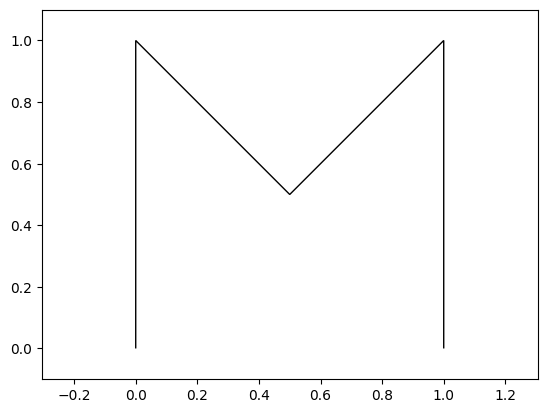

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mplb

# 5 corners of the letter M
path = np.array(
        [[0, 0.],
        [0, 1.],
        [.5, .5],
        [1., 1.],
        [1., 0.]])
def plot_path(ax, path, m='k'):
    ax.add_patch(mplb.patches.PathPatch(mplb.path.Path(path), fill=False, color=m))
    # ax.set_xlim(-0.1, 1.1)
    # ax.set_ylim(-0.1, 1.1)
    ax.axis('equal')
    return ax

fig, ax = plt.subplots()
plot_path(ax, path)
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)

In [3]:
R = rot2D(np.pi/6)
# the coordinates must be the column vectors in a matrix
# path contains coordinates as the row vectors.
# Transpose the path and take the transpose of the result
rotated_path = (R @ path.T).T

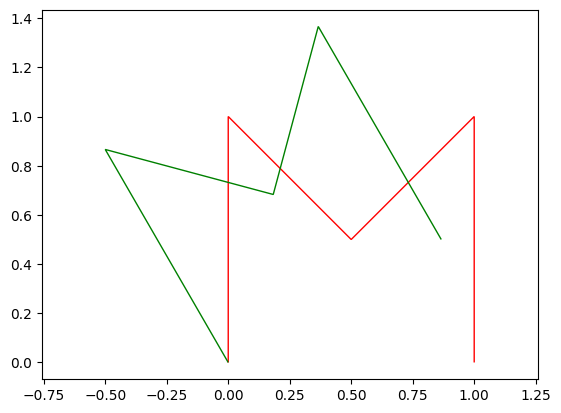

In [4]:


fig, ax = plt.subplots()
plot_path(ax, path, m='r')
plot_path(ax, rotated_path, m='g')
plt.show()

## Can we rotate an image?

In [5]:
FILELOCATION = "umaine.png"
import urllib
with urllib.request.urlopen("https://raw.githubusercontent.com/wecacuee/gazebo_osm/1e7f7a5bfed1e9a1bd60848bbf15d16fc4b1ccbf/testFiles/umaine.png") as uf:
    with open("umaine.png", "wb") as wf:
        wf.write(uf.read())
        

In [6]:
import matplotlib.pyplot as plt
im = plt.imread("umaine.png")

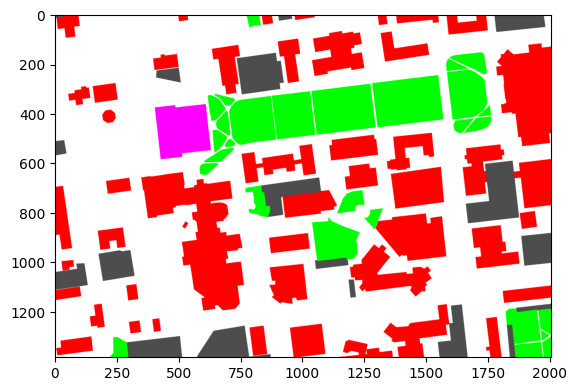

In [7]:
plt.imshow(im)

In [8]:
import numpy as np
# Generate a grid of all coordinates in the image
x, y = np.mgrid[0:im.shape[1], 0:im.shape[0]]

In [9]:
R = rot2D(np.pi/6)

In [10]:
# Concatenate x, y coordinates along the last axis to form vectors
p = np.concatenate((x[..., None], y[..., None]), axis=-1)

In [11]:
# Handle np.matmul quirkiness for matrix vector multiplication, but for 
# all points in the grid.
rotp = (R @ p[..., None])[..., 0]

In [12]:
# Convert the points to nearest integer
rotpi = np.round(rotp).astype('i8')

# Separate x and y
rx = rotpi[..., 0]
ry = rotpi[..., 1]

In [13]:
# make the image slightly bigger to account for the roatated image
rotim = np.zeros((3*im.shape[0]//2, 3*im.shape[1]//2, im.shape[2]))

# Convert x, y to row, col
rr = rotim.shape[0]-ry-1
rfilter = (0 <= rr) & (rr < rotim.shape[0])
rc = rx
cfilter = (0 <= rc) & (rc < rotim.shape[1])
inbounds = rfilter & cfilter

# Generate image within the same bounds
rotim[rr[inbounds], rc[inbounds], :] = im[im.shape[0]-y[inbounds]-1, x[inbounds], :]

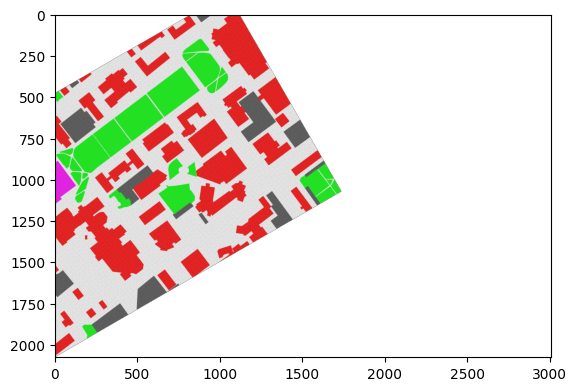

In [14]:
plt.imshow(rotim)

## How to rotate around center then?

Create a new coordinate frame at the center of the object, rotate the coordinates in the new coordinate frame then translate back to the original coordinate frame.

$ \mathbf{p}' = R(\mathbf{p}-\mathbf{t}_{center})+\mathbf{t}_{center} $

In [15]:
def rot2D_around_center(R, points):
    tcenter = np.mean(points, axis=-2, keepdims=True)
    return (R @ (points - tcenter)[..., None] + tcenter)[..., 0]

<Axes: >

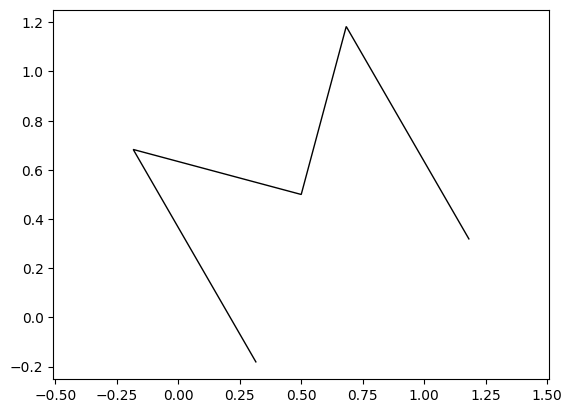

In [16]:
rotpath = rot2D_around_center(rot2D(np.pi/6), path)

fig, ax = plt.subplots()
plot_path(ax, rotpath)

In [17]:
rotp = rot2D_around_center(rot2D(np.pi/6), p.reshape(-1, 2)).reshape(*p.shape)

In [18]:
# Convert the points to nearest integer
rotpi = np.round(rotp).astype('i8')

# Separate x and y
rx = rotpi[..., 0]
ry = rotpi[..., 1]

In [19]:
# make the image slightly bigger to account for the roatated image
rotim = np.zeros((3*im.shape[0]//2, im.shape[1], im.shape[2]))

# Convert x, y to row, col
rr = rotim.shape[0]-ry-1
rfilter = (0 <= rr) & (rr < rotim.shape[0])
rc = rx
cfilter = (0 <= rc) & (rc < rotim.shape[1])
inbounds = rfilter & cfilter

# Generate image within the same bounds
rotim[rr[inbounds], rc[inbounds], :] = im[im.shape[0]-y[inbounds]-1, x[inbounds], :]

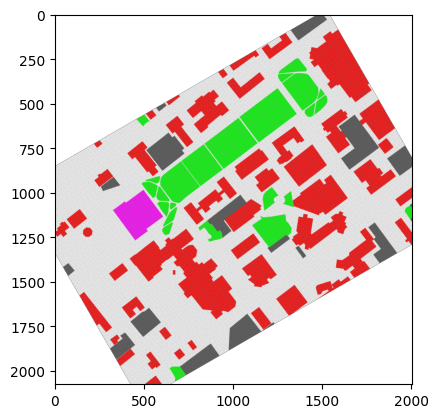

In [20]:
plt.imshow(rotim)

## 3D Rotation demo

We are going to use plotly for 3D rotation demo. Matplotlib has support for 3D plots, but it is not as cool as plotly. Documentation here :
<https://plotly.com/python/3d-mesh/>

In [21]:
!pip install -U pip plotly

Let's make a 3D M out of points and triangles. But before we make M 3D, we need to make M thik in 2D.

[[-0.5  0. ]
 [-0.5  1. ]
 [ 0.   0.5]
 [ 0.5  1. ]
 [ 0.5  0. ]
 [ 0.4  0. ]
 [ 0.4  0.8]
 [ 0.   0.4]
 [-0.4  0.8]
 [-0.4  0. ]]


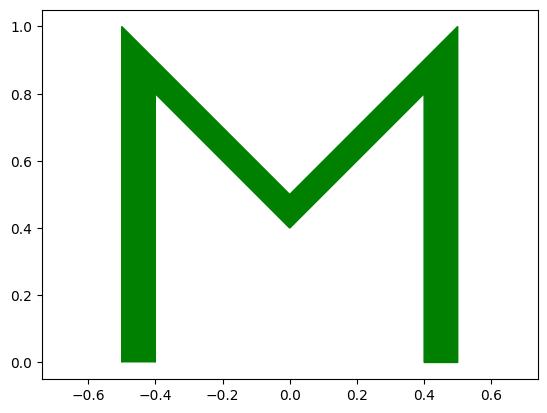

In [22]:
import matplotlib.pyplot as plt
import matplotlib as mplb
import numpy as np

# 5 corners of the letter M
path = np.array(
        [[0, 0.],
        [0, 1.],
        [.5, .5],
        [1., 1.],
        [1., 0.]])
path -= np.array([0.5, 0.]) # Shift M so that the center is at middle of M
npts = path.shape[0] # How many points?
filled_path_for_M = np.zeros((2*npts, 2))
filled_path_for_M[:npts, :] = path # Copy first set of points
filled_path_for_M[npts:, :] = 0.8*path[::-1] # Copy second set of points but reversed
print(filled_path_for_M)
fig, ax = plt.subplots()
ax.add_patch(mplb.patches.PathPatch(mplb.path.Path(filled_path_for_M), fill=True, color='g'))
ax.set_xlim(-0.6, 0.6)
ax.set_ylim(-0.1, 1.1)
ax.axis('equal')
plt.show()



In [23]:
import plotly.graph_objects as go

path3D = np.zeros((4*npts, 3)) # extend the path to 3D with 4 times the points
# We will have 2 copies of filled_path_for_M
# Copy 1: with z = 0 and original X, Y
# Copy 2: with z = 0.1 and original X, Y
path3D[:2*npts, :2] = filled_path_for_M # copy the 2D points
path3D[:2*npts, 2] = 0 # make z coordinate zero for first set of points

# Copy 2: with z = 0.1 and original X, Y
path3D[2*npts:, :2] = filled_path_for_M # copy the 2D points another time
path3D[2*npts:, 2] = 0.1 # make z coordinate 0.1 for second set of points

# We will need a lot of triangles
pointids = np.arange(path3D.shape[0], dtype='i8')
# Number of rects required for filling up M at z = 0
rects = np.zeros(((npts-1), 4), dtype='i8')
rects[:, 0] = pointids[:npts-1]
rects[:, 1] = pointids[1:npts]
rects[:, 2] = pointids[2*npts-2:npts-1:-1]
rects[:, 3] = pointids[2*npts-1:npts:-1]

# Number of rects required for filling up M at z = 0.1
pointids_z1 = pointids[2*npts:]
rects2 = np.zeros(((npts-1), 4))
rects2[:, 0] = pointids_z1[:npts-1]
rects2[:, 1] = pointids_z1[1:npts]
rects2[:, 2] = pointids_z1[2*npts-2:npts-1:-1]
rects2[:, 3] = pointids_z1[2*npts-1:npts:-1]
rects = np.vstack((rects, rects2))

# Number of rects required to connect lower M and upper M
rects3 = np.zeros((2*npts, 4), dtype='i8')
rects3[:, 0] = pointids[:2*npts]
rects3[:, 1] = pointids_z1
rects3[:, 2] = np.roll(pointids_z1, 1)
rects3[:, 3] = np.roll(pointids[:2*npts], 1)
rects = np.vstack((rects, rects3))

# Breakdown rects into triangles along the diagonal
nrects = rects.shape[0]
triangles = np.zeros((2*nrects, 3), dtype='i8')
triangles[:nrects, 0] = rects[:, 0]
triangles[:nrects, 1] = rects[:, 1]
triangles[:nrects, 2] = rects[:, 3]
triangles[nrects:, 0] = rects[:, 2]
triangles[nrects:, 1] = rects[:, 1]
triangles[nrects:, 2] = rects[:, 3]

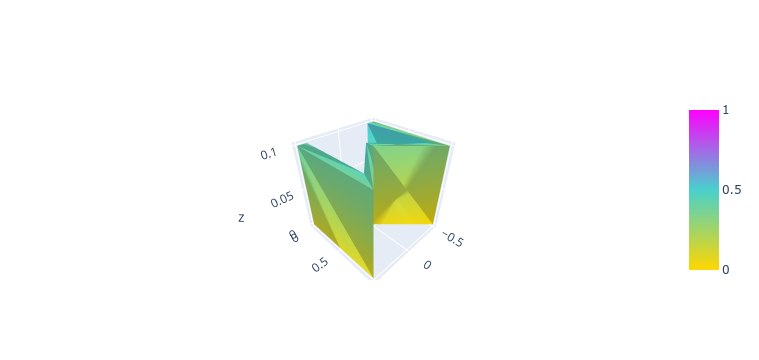

In [24]:

fig = go.Figure(
    layout=go.Layout(
        xaxis=dict(range=[-1, 1], autorange=False),
        yaxis=dict(range=[-1, 1], autorange=False)
    ),
    data=[
        go.Mesh3d(
            # 10 vertices of a M
            x=path3D[:, 0],
            y=path3D[:, 1],
            z=path3D[:, 2],
            # colorbar_title='z',
            colorscale=[[0, 'gold'],
                        [0.5, 'mediumturquoise'],
                        [1, 'magenta']],
            # Intensity of each vertex, which will be interpolated and color-coded
            intensity = np.linspace(0, 1, triangles.shape[0],  endpoint=True),
            intensitymode='vertex',
            i=triangles[:, 0],
            j=triangles[:, 1],
            k=triangles[:, 2],
            name='y',
            showscale=True
        ),
    ]
)


fig.show()

In [25]:
def cross_prod(k):
    return np.array([[    0, -k[2],  k[1]],
                     [ k[2],     0, -k[0]],
                     [-k[1],  k[0],    0]])
def rot3D(k, theta):
    k = k / np.linalg.norm(k)
    K = cross_prod(k)
    return np.eye(3) + np.sin(theta) * K + (1-np.cos(theta)) * K @ K
k = np.array([1., 1, 0])

## 3D animation using k3d

This does not work in Google Colab, but can work in binder: 
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/wecacuee/ECE417-F24-Mobile-Robots/HEAD?labpath=docs%2Fnotebooks%2F02-18-rot%2FRotationDemo.ipynb)

In [26]:
!pip install -U k3d

In [27]:
import k3d
import numpy as np
from k3d import matplotlib_color_maps

def rotated_points(k, theta, points):
    return (rot3D(k, theta) @ points.T).T

k = np.array([0., 1., 0.])
plot = k3d.plot()
plot += k3d.line(vertices=np.vstack(([[0., 0., 0.]], k[None, :])).astype('f4'),
                color=0xFF0000)
                                   
plt_mesh = k3d.mesh(vertices=path3D.astype('f4'), indices=triangles.astype('u4'),
                    opacity=0.75)
plot += plt_mesh
plot.display()


Output()

In [28]:

k = np.array([1., 1., 0.]) # try variations of [1., 0., 0.], [0, 0, 1], [1, 1, 0], [0, 1, 1]

plot = k3d.plot()
plot += k3d.line(vertices=np.vstack(([[0., 0., 0.]], k[None, :])).astype('f4'),
                color=0xFF0000)
                                   
plt_mesh = k3d.mesh(vertices=path3D.astype('f4'), indices=triangles.astype('u4'),
                    opacity=0.75)
plot += plt_mesh
plot.display()

plt_mesh.vertices = {str(t/10.): rotated_points(k, t*2*np.pi/99, path3D).astype('f4') for t in range(100)}
plot.start_auto_play()

Output()